In [1]:
import numpy as np

y_true = np.array([0]*95 + [1]*5)
y_pred = np.zeros_like(y_true)

acc = (y_true == y_pred).mean()
acc

np.float64(0.95)

In [2]:
from sklearn.datasets import make_classification
import numpy as np

X, y = make_classification(
    n_samples=4000,
    n_features=20,
    n_informative=6,
    n_redundant=4,
    n_clusters_per_class=2,
    weights=[0.95, 0.05],
    flip_y=0.01,
    class_sep=1.0,
    random_state=42
)

pos_rate = y.mean()
X.shape, pos_rate


((4000, 20), np.float64(0.054))

Why not a single train/test split?
• results depend on the random seed
• one split can be unusually easy/hard
• high variance estimate

Cross-validation:
• repeat evaluation across folds
• average results → more stable



StratifiedKFold
Definition:
StratifiedKFold keeps class proportions approximately the same in each fold.

Why:
• prevents folds with near-zero positives
• makes metrics comparable across folds



In [3]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for i, (_, val_idx) in enumerate(skf.split(X, y), start=1):
    fold_rate = y[val_idx].mean()
    print(f"Fold {i}: positive rate = {fold_rate:.4f}")

Fold 1: positive rate = 0.0537
Fold 2: positive rate = 0.0537
Fold 3: positive rate = 0.0537
Fold 4: positive rate = 0.0537
Fold 5: positive rate = 0.0550


Rule:
Any step that “learns from data” must be fit ONLY on training data.

Examples:
• scaling (mean/std)
• imputation (median/mode)
• encoding categories (vocabulary)
• feature selection (top-k)
• resampling (over/under-sampling)



In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000))
])

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

# WRONG: fit scaler on all data, then CV
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # leakage
wrong = cross_val_score(LogisticRegression(max_iter=3000), X_scaled, y, cv=skf, scoring="f1")

# RIGHT: pipeline; scaler fit within each fold
right = cross_val_score(pipe_lr, X, y, cv=skf, scoring="f1")


In [7]:
wrong.mean(), right.mean(), wrong.std(), right.std()

(np.float64(0.5973825583170165),
 np.float64(0.5916837794839093),
 np.float64(0.04731559595484046),
 np.float64(0.04459203195531581))

Metrics we will use today (imbalanced binary classification)
• ROC-AUC (ranking ability)
• PR-AUC / Average Precision (focus on positives)
• F1 (threshold-dependent)
Optional:
• MCC (balanced single number)


In [8]:
from sklearn.model_selection import cross_validate

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1"
}

res = cross_validate(pipe_lr, X, y, cv=skf, scoring=scoring, return_train_score=False)
{m: (res["test_"+m].mean(), res["test_"+m].std()) for m in scoring}

{'roc_auc': (np.float64(0.9090722485449223), np.float64(0.03566076762484851)),
 'pr_auc': (np.float64(0.7031565980038319), np.float64(0.08670378553117343)),
 'f1': (np.float64(0.5916837794839093), np.float64(0.04459203195531581))}

ROC vs PR curves
ROC curve:
• x-axis = FPR = FP / (FP + TN)
• y-axis = TPR = Recall = TP / (TP + FN)

PR curve:
• x-axis = Recall
• y-axis = Precision = TP / (TP + FP)

Why PR can be better for imbalance:
• PR ignores TN (true negatives)
• focuses on how “clean” positive predictions are

In [9]:
from sklearn.model_selection import cross_val_predict
import numpy as np

# Out-of-fold predicted probabilities (each point predicted by a model that did NOT train on it)
oof_probs = cross_val_predict(pipe_lr, X, y, cv=skf, method="predict_proba")[:, 1]
oof_probs[:5]


array([6.54464647e-02, 9.78742816e-02, 9.14541848e-02, 7.72979848e-05,
       4.66425687e-02])

In [11]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
fpr, tpr, roc_thr = roc_curve(y, oof_probs)
prec, rec, pr_thr = precision_recall_curve(y, oof_probs)

roc_auc = roc_auc_score(y, oof_probs)
pr_auc = average_precision_score(y, oof_probs)

roc_auc, pr_auc

(np.float64(0.9060542439902906), np.float64(0.6901155262871237))

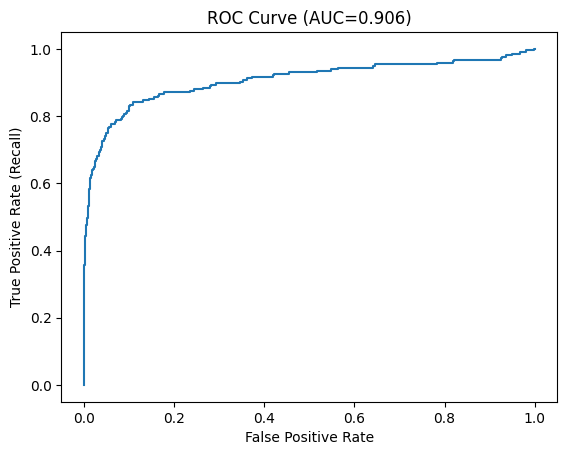

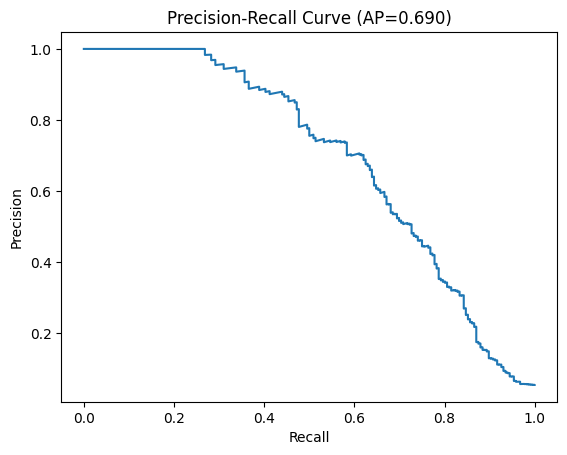

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title(f"ROC Curve (AUC={roc_auc:.3f})")
plt.show()

plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP={pr_auc:.3f})")
plt.show()

Hyperparameter tuning with GridSearchCV
Definition:
Hyperparameters are settings not learned from data (example: C in logistic regression).

Rule:
Tune hyperparameters using CV on training data only.
Do not tune on the test set.

We will tune using:
• Pipeline (prevents leakage)
• StratifiedKFold (stable folds)
• PR-AUC scoring (appropriate for imbalance)


In [13]:
from sklearn.model_selection import GridSearchCV

pipe_lr_bal = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

search = GridSearchCV(
    estimator=pipe_lr_bal,
    param_grid=param_grid,
    scoring="average_precision",
    cv=skf,
    n_jobs=-1,
    return_train_score=False
)

search.fit(X, y)
search.best_params_, search.best_score_


({'model__C': 0.01}, np.float64(0.6869569449758658))

Imbalance handling methods (quick experiment)
Method A: class weights
• change training loss

Method B: resampling
• change training data distribution (train only!)

Important:
Resampling must be done inside each CV fold to avoid leakage.



In [15]:
import numpy as np
from sklearn.metrics import average_precision_score
from sklearn.base import clone

def undersample_train(X_tr, y_tr, random_state=42):
    rng = np.random.default_rng(random_state)
    pos_idx = np.where(y_tr == 1)[0]
    neg_idx = np.where(y_tr == 0)[0]
    # Undersample negatives to match positives (1:1)
    neg_keep = rng.choice(neg_idx, size=len(pos_idx), replace=False)
    keep_idx = np.concatenate([pos_idx, neg_keep])
    rng.shuffle(keep_idx)
    return X_tr[keep_idx], y_tr[keep_idx]

def cv_pr_auc_with_optional_undersample(pipeline, X, y, cv, do_undersample=False):
    scores = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), start=1):
        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_va, y_va = X[va_idx], y[va_idx]

        if do_undersample:
            X_tr, y_tr = undersample_train(X_tr, y_tr, random_state=100+fold)

        model = clone(pipeline)
        model.fit(X_tr, y_tr)
        probs = model.predict_proba(X_va)[:, 1]
        scores.append(average_precision_score(y_va, probs))
    return np.mean(scores), np.std(scores)

# Pipelines to compare
pipe_unweighted = Pipeline([("scaler", StandardScaler()),
                            ("model", LogisticRegression(max_iter=5000))])

pipe_weighted = Pipeline([("scaler", StandardScaler()),
                          ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))])

mean_u, std_u = cv_pr_auc_with_optional_undersample(pipe_unweighted, X, y, skf, do_undersample=False)
mean_w, std_w = cv_pr_auc_with_optional_undersample(pipe_weighted, X, y, skf, do_undersample=False)
mean_r, std_r = cv_pr_auc_with_optional_undersample(pipe_unweighted, X, y, skf, do_undersample=True)



Threshold tuning
Definition:
A threshold t converts probabilities into labels:
predict 1 if p ≥ t

Key points:
• default t=0.5 is arbitrary
• tune threshold to match your goal (F1, recall target, precision target)

We will:
• pick t to maximize F1 on validation predictions


In [16]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

thresholds = np.linspace(0.0, 1.0, 101)

f1_list, p_list, r_list = [], [], []
for t in thresholds:
    y_hat = (oof_probs >= t).astype(int)
    f1_list.append(f1_score(y, y_hat))
    p_list.append(precision_score(y, y_hat, zero_division=0))
    r_list.append(recall_score(y, y_hat, zero_division=0))

best_idx = int(np.argmax(f1_list))
best_t = thresholds[best_idx]
best_t, f1_list[best_idx], p_list[best_idx], r_list[best_idx]


(np.float64(0.32), 0.6567901234567901, 0.7037037037037037, 0.6157407407407407)

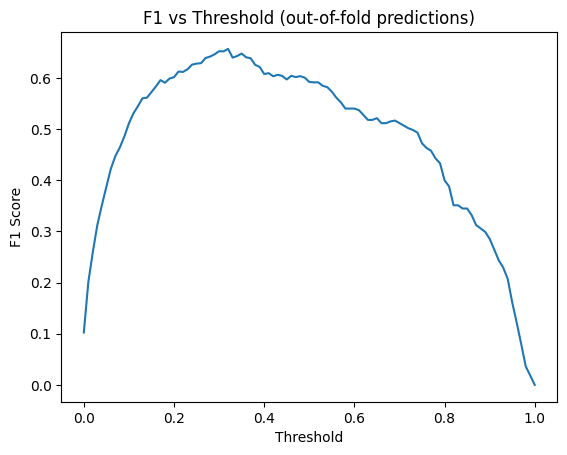

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(thresholds, f1_list)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 vs Threshold (out-of-fold predictions)")
plt.show()


What you should do in your own modeling work

Choose metrics that match the problem (often PR-AUC / F1 / MCC for imbalance)

Use StratifiedKFold for imbalanced classification

Put preprocessing inside a Pipeline

Tune hyperparameters with GridSearchCV (metric = your goal)

Consider class weights; resample only inside training folds

Tune thresholds if you care about precision/recall trade-offs

Report mean ± std; record random_state and split strategy

MCC (Matthews Correlation Coefficient)

Definition:
A balanced correlation-based metric using all four confusion matrix cells.

Range:
-1 (perfectly wrong) to 0 (random) to +1 (perfect)

WHITEBOARD (word-for-word)
MCC =
(TP × TN − FP × FN) / sqrt((TP+FP)(TP+FN)(TN+FP)(TN+FN))

In [18]:
from sklearn.metrics import matthews_corrcoef, make_scorer
from sklearn.model_selection import cross_val_score

mcc = make_scorer(matthews_corrcoef)
scores = cross_val_score(pipe_lr, X, y, cv=skf, scoring=mcc)
scores.mean(), scores.std()

(np.float64(0.6080140272926498), np.float64(0.04778249269009726))